## Testing for habitat preferences in Pangolin with hrRSF

In [2]:
%load_ext autoreload
%autoreload 2

This notebook provides a full workflow for testing certain hypotheses with respect to habitat preferences in Ground pangolin, as have been developed in the course of extensive field observations, namely:

I\ That pangolin avoid large slopes (base hypothesis to check whether the Bayesian approach is working)

II\ That pangolin prefer forest-edge structure, i.e., areas where dense bush is adjacent to more open spaces.

#### 1. Preparation

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import geopandas as gpd
from shapely import Polygon
import ee, geemap
import geemap.colormaps as cm

In [4]:
from hsa.compute import make_local_dask_client
client = make_local_dask_client(n_workers=10,
                                threads_per_worker=1,
                                memory_limit="10GiB",
                                local_directory='dask-tmp')
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 10
Total threads: 10,Total memory: 100.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:35509,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:39385,Total threads: 1
Dashboard: http://127.0.0.1:43245/status,Memory: 10.00 GiB
Nanny: tcp://127.0.0.1:33917,


In [5]:
from hsa.compute import initialize_earth_engine_on_workers
initialize_earth_engine_on_workers(client = client, project = "test-with-greta")

{'tcp://127.0.0.1:34351': True,
 'tcp://127.0.0.1:35493': True,
 'tcp://127.0.0.1:38775': True,
 'tcp://127.0.0.1:39385': True,
 'tcp://127.0.0.1:40887': True,
 'tcp://127.0.0.1:42243': True,
 'tcp://127.0.0.1:43933': True,
 'tcp://127.0.0.1:45871': True,
 'tcp://127.0.0.1:46089': True,
 'tcp://127.0.0.1:46351': True}

##### 1.1 Pangolin Relocations

In [6]:
from hsa.movement.geometry import prepare_trajectory_data
df = pd.read_csv("data/relocations/pango_subset.csv")
reloc = prepare_trajectory_data(df, geometry_col="geometry", source_crs = "EPSG:32733", target_crs = "EPSG:32733")

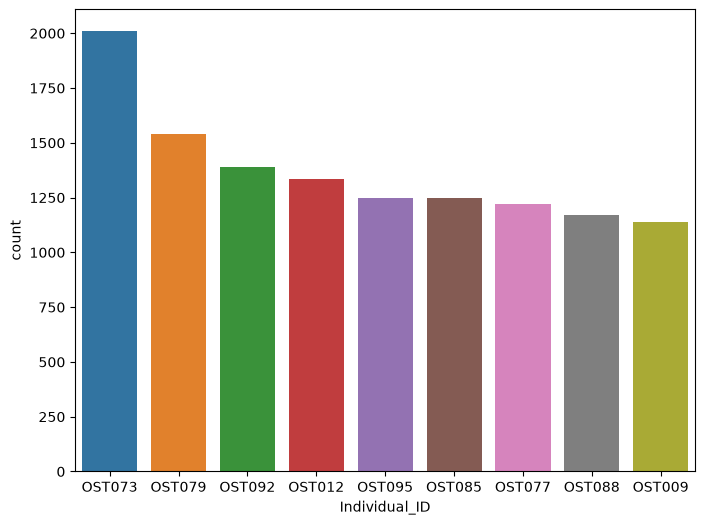

In [7]:
fig, ax = plt.subplots(figsize = (8, 6))
count_by_id = reloc.groupby("Individual_ID").size().rename("count").sort_values(ascending = False).reset_index()
sns.barplot(count_by_id, x = "Individual_ID", y = "count", hue = "Individual_ID")
plt.show()

#### 1.2 Prepare Environmental Layer

##### 1.2.1 Set-Up Remote Sensing Bench

In [8]:
EE_PROJECT = 'test-with-greta'  # change if needed
TARGET_CRS = 'EPSG:32733'
EXPORT_SCALE = 30
BUFFER_M = 0

SHAPES = Path('data/vectors')
PERIMETER_FILE = SHAPES / 'onr_perimeter.shp'
OUT_ZARR = Path('env_32733.zarr')

START = reloc["Timestamp"].min()
END = reloc["Timestamp"].max()

In [9]:
from hsa.remote_sensing import initialize_earth_engine
e = initialize_earth_engine(project=EE_PROJECT)

perimeter_raw = gpd.read_file(PERIMETER_FILE, engine='pyogrio')
perimeter = gpd.GeoDataFrame(
    geometry=[Polygon(perimeter_raw.geometry.iloc[0])],
    crs=perimeter_raw.crs,
).to_crs(TARGET_CRS)

aoi = gpd.GeoDataFrame(geometry=perimeter.geometry.buffer(BUFFER_M), crs=TARGET_CRS)
aoi_wgs84 = aoi.to_crs('EPSG:4326')
aoi_ee = geemap.geopandas_to_ee(aoi_wgs84)

def reset_map():
    Map = geemap.Map()
    Map.addLayer(aoi_ee, {}, "AOI")
    Map.centerObject(aoi_ee, zoom = 10)
    return Map

#### 1.2.2  Water mask

In [10]:
def mask_s2_clouds(image):
    qa = image.select("QA60")

    cloud_bit_mask = 1 << 10
    cirrus_bit_mask = 1 << 11

    mask = (
        qa.bitwiseAnd(cloud_bit_mask).eq(0)
        .And(qa.bitwiseAnd(cirrus_bit_mask).eq(0))
    )

    optical = (
        image.updateMask(mask)
        .select(
            ["B2", "B3", "B4", "B8", "B11", "B12"],
            ["blue", "green", "red", "nir", "swir1", "swir2"],
        )
        .divide(10000)
    )

    return optical.copyProperties(image, ["system:time_start"])

In [11]:
def add_water_index(image):
    mndwi = image.normalizedDifference(["green", "swir1"]).rename("mndwi")
    return image.addBands(mndwi)

In [12]:
s2 = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterBounds(aoi_ee.geometry())
    .filterDate(START, END)
    .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 20))
    .map(mask_s2_clouds)
    .map(add_water_index)
)

In [13]:
mndwi_water = s2.select("mndwi").max().clip(aoi_ee)

Map = reset_map()
Map.addLayer(mndwi_water, {"min": 0, "max": 1, "palette": cm.palettes.Blues}, "MNDWI")
Map.addLayer(mndwi_water.gt(0.6))
Map

Map(center=[-20.80767941988962, 16.63538393863364], controls=(WidgetControl(options=['position', 'transparent_…

In [14]:
water = mndwi_water.gt(0.6)
land_mask = water.Not()

#### 1.2.3 Acquire imagery & calculate indeces

In [15]:
# Sentinel-1
s1 = (
    ee.ImageCollection("COPERNICUS/S1_GRD")
    .filter(ee.Filter.eq("instrumentMode", "IW"))
    .filter(ee.Filter.eq("orbitProperties_pass", "ASCENDING"))
    .filterDate(START, END)
    .filterBounds(aoi_ee.geometry())
)

In [16]:
# ---------------------
# Calculate S1 Indices
# ---------------------
def add_s1_indices(image):

    vv = image.select("VV")
    vh = image.select("VH")

    vv_vh_diff = vv.subtract(vh).rename("vv_vh_diff")

    vv_lin = ee.Image(10).pow(vv.divide(10)).rename("vv_linear")
    vh_lin = ee.Image(10).pow(vh.divide(10)).rename("vh_linear")

    vv_vh_ratio = vv_lin.divide(vh_lin).rename("vv_vh_ratio")

    return image.addBands([
        vv_vh_diff,
        vv_lin,
        vh_lin,
        vv_vh_ratio,
    ])

s1 = s1.map(add_s1_indices)

In [17]:
def add_s2_indices(image):
    ndvi = image.normalizedDifference(["nir", "red"]).rename("ndvi")
    ndmi = image.normalizedDifference(["nir", "swir1"]).rename("ndmi")
    mndwi = image.normalizedDifference(["green", "swir1"]).rename("mndwi")

    bsi = (
        image.select("swir1").add(image.select("red"))
        .subtract(image.select("nir")).subtract(image.select("blue"))
        .divide(
            image.select("swir1").add(image.select("red"))
            .add(image.select("nir")).add(image.select("blue"))
        )
        .rename("bsi")
    )

    savi = (
        image.select("nir").subtract(image.select("red"))
        .multiply(1.5)
        .divide(image.select("nir").add(image.select("red")).add(0.5))
        .rename("savi")
    )

    return image.addBands([ndvi, ndmi, mndwi, bsi, savi])

s2 = s2.map(add_s2_indices)

#### 1.5 Construct the Landscape

In [18]:
Map = reset_map()
Map

Map(center=[-20.80767941988962, 16.63538393863364], controls=(WidgetControl(options=['position', 'transparent_…

In [19]:
vv_median = s1.select("VV").median().clip(aoi_ee)
vh_median = s1.select("VH").median().clip(aoi_ee)
vv_vh_diff_median = s1.select("vv_vh_diff").median().clip(aoi_ee)

Map.addLayer(
    ee.Image.cat([vv_median, vh_median, vv_vh_diff_median]),
    {
        "bands": ["VV", "VH", "vv_vh_diff"],
        "min": [-18, -25, 2],
        "max": [-5, -12, 12],
    },
    "S1 False Color Composite")

red = s2.select("red").median().clip(aoi_ee)
green = s2.select("green").median().clip(aoi_ee)
blue = s2.select("blue").median().clip(aoi_ee)

Map.addLayer(
    ee.Image.cat([red, green, blue]),
    {
        "bands": ["red", "green", "blue"],
        "min": 0.02,
        "max": 0.35,
    },
    "S2 True Colour Composite"
)

In [20]:
Map.addLayer(s1.select("vv_vh_ratio").median().clip(aoi_ee), {"min": 1, "max": 8, "palette": cm.palettes.inferno}, "VV/VH")
Map.addLayer(s2.select("ndvi").median().clip(aoi_ee), {"min": 0, "max": 0.55, "palette": cm.palettes.Greens}, "NDVI")
Map.addLayer(s2.select("savi").median().clip(aoi_ee), {"min": 0, "max": 0.55, "palette": cm.palettes.Greens}, "SAVI")
Map.addLayer(s2.select("bsi").median().clip(aoi_ee), {"min": -0.5, "max": 0.5, "palette": cm.palettes.hot}, "BSI")

#### 1.6 Apply transformations

In [21]:
# ------------------------------------------------------------
# SAR structural edge layer from Sentinel-1 VH
# ------------------------------------------------------------

def make_vh_edge_layers(vh, land_mask, *, smooth_radius, density_radii=(50, 100, 250)):
    vh_smooth = (
        vh.median()
        .updateMask(land_mask)
        .focal_mean(radius=smooth_radius, units="meters")
        .rename(f"vh_smooth_{smooth_radius}m")
    )

    edge = ee.Algorithms.CannyEdgeDetector(
        image=vh_smooth,
        threshold=1,
        sigma=1,
    ).rename(f"vh_edge_smooth_{smooth_radius}m")

    dist = (
        edge.fastDistanceTransform(256)
        .sqrt()
        .multiply(10)
        .rename(f"dist_to_vh_edge_smooth_{smooth_radius}m")
    )

    densities = [
        edge.unmask(0)
        .focal_mean(radius=r, units="meters")
        .rename(f"edge_density_{r}m_from_vh_smooth_{smooth_radius}m")
        for r in density_radii
    ]

    return ee.Image.cat([vh_smooth, edge, dist, *densities])

edge_stack = ee.Image.cat([
    make_vh_edge_layers(s1.select("VH"), land_mask, smooth_radius=30),
    make_vh_edge_layers(s1.select("VH"), land_mask, smooth_radius=100),
    make_vh_edge_layers(s1.select("VH"), land_mask, smooth_radius=250),
])

In [22]:
# ------------------------------------------------------------
# Compositional layer from Sentinel-1 VH
# ------------------------------------------------------------

ndvi_30m = s2.select("ndvi").median().updateMask(land_mask).rename("ndvi_30m")

ndvi_100m = (
    s2.select("ndvi").median()
    .updateMask(land_mask)
    .focal_mean(radius=100, units="meters")
    .rename("ndvi_mean_100m")
)

ndvi_250m = (
    s2.select("ndvi").median()
    .updateMask(land_mask)
    .focal_mean(radius=250, units="meters")
    .rename("ndvi_mean_250m")
)

ndvi_stack = ee.Image.cat([ndvi_30m, ndvi_100m, ndvi_250m])

In [23]:
# ------------------------------------------------------------
# Optical bare-ground edge layer from Sentinel-2 BSI
# ------------------------------------------------------------

PIXEL_SIZE_M = 10

def make_bsi_edge_layers(
    bsi,
    land_mask,
    *,
    smooth_radius,
    density_radii=(50, 100, 250),
    threshold=0.02,
    sigma=1,
    max_distance_pixels=256,
):
    bsi_smooth = (
        bsi
        .updateMask(land_mask)
        .focal_mean(radius=smooth_radius, units="meters")
        .rename(f"bsi_smooth_{smooth_radius}m")
    )

    bsi_edge = ee.Algorithms.CannyEdgeDetector(
        image=bsi_smooth,
        threshold=threshold,
        sigma=sigma,
    ).rename(f"bsi_edge_smooth_{smooth_radius}m")

    dist_to_bsi_edge = (
        bsi_edge
        .fastDistanceTransform(max_distance_pixels)
        .sqrt()
        .multiply(PIXEL_SIZE_M)
        .rename(f"dist_to_bsi_edge_smooth_{smooth_radius}m")
    )

    densities = [
        bsi_edge
        .unmask(0)
        .focal_mean(radius=r, units="meters")
        .rename(f"bsi_edge_density_{r}m_from_smooth_{smooth_radius}m")
        for r in density_radii
    ]

    return ee.Image.cat([
        bsi_smooth,
        bsi_edge,
        dist_to_bsi_edge,
        *densities,
    ])

bsi_base = s2.select("bsi").median().clip(aoi_ee)

bsi_edge_stack = ee.Image.cat([
    make_bsi_edge_layers(bsi_base, land_mask, smooth_radius=30),
    make_bsi_edge_layers(bsi_base, land_mask, smooth_radius=100),
    make_bsi_edge_layers(bsi_base, land_mask, smooth_radius=250),
])

#### 1.7 Additional Layers for Bayesian Approach

In [45]:
dem = ee.Image("USGS/SRTMGL1_003").clip(aoi_ee).select("elevation")
slope = ee.Terrain.slope(dem).rename("slope")

sand = ee.Image("ISDASOIL/Africa/v1/sand_content").clip(aoi_ee).select("mean_0_20")
clay = ee.Image("ISDASOIL/Africa/v1/clay_content").clip(aoi_ee).select("mean_0_20")

#### 1.8 Export

In [47]:
stack = ee.Image.cat([
    edge_stack,
    ndvi_stack,
    bsi_edge_stack,
    dem, slope,
    sand, clay
])

In [48]:
from hsa.remote_sensing import ee_image_to_xarray_stack
from hsa.compute import suggest_xy_chunks, persist_if_dask, write_raster_stack_zarr

env = ee_image_to_xarray_stack(
    stack,
    geometry=aoi_ee.geometry(),
    crs="EPSG:32733",
    scale=100,
)

In [49]:
env = write_raster_stack_zarr(env, "pangolin_predictor_stack.zarr")

### 2. Produce the dataset for estimation

In [ ]:
from hsa.compute import open_raster_stack_zarr
from hsa.compute import suggest_xy_chunks
import xarray as xr

env = open_raster_stack_zarr("edge.zarr")
env = env.chunk(suggest_xy_chunks(env, target_chunk_mb=256))

In [ ]:
from hsa.sampling import get_availability_domain, sample_available_points, sample_raster_stack
domains = get_availability_domain(reloc, id_col="Individual_ID")
sampling = sample_available_points(domains, used = reloc, n_per_used = 10, id_col = "Individual_ID")
sampled = sample_raster_stack(sampling, env, id_cols="Individual_ID")

In [ ]:
# -------------------------
# Visual Inspection
# -------------------------

from hsa.diagnostics import inspect_sampled_use_available
res = inspect_sampled_use_available(sampled, plot = True)

In [ ]:
# -------------------------
# Model comparison via AIC
# -------------------------
from hsa.rsf import compare_single_predictors, evaluate_linear_candidates_up_to_k
lk = compare_single_predictors(sampled)

In [ ]:
# -------------------------
# Fitting a ML-Model
# -------------------------
from hsa.features import FeatureSpec
from hsa.rsf import fit_rsf

specs = FeatureSpec(linear = ["vh_smooth_30m"])
model, scaler, spec, meta = fit_rsf(sampled[sampled["Individual_ID"].isin(["OST077", "OST085", "OST088"])], specs)
model.summary()

In [ ]:
# -------------------------
# Fit surface
# -------------------------
import numpy as np
from hsa.rsf import predict_rsf_surface

rsf = predict_rsf_surface(env, model, scaler, spec, meta)
rsf["exp"] = np.exp(rsf)

fig, ax = plt.subplots(figsize = (12, 8))
rsf["exp"].plot(ax = ax)
ax.axis("equal")
#reloc.plot(ax = ax, color = "red", alpha = 0.01)
ax.set_axis_off()
plt.show()

In [ ]:
from hsa.rsf.cv import leave_one_individual_out_rsf
from hsa.rsf.validation import plot_boyce_curves
spec = FeatureSpec(linear = ["ndvi_30m"])

summary, params, boyce_bins, calibration_bins, diagnostics = (
    leave_one_individual_out_rsf(
        reloc[reloc["Individual_ID"].isin(["OST077", "OST085", "OST088"])],
        env,
        spec,
        id_col="Individual_ID",
        #heldout=["OST009"],
        sampling_factor_train=100,
        n_background_boyce=100_000,
        calibration_n_background=100_000,
        calibration_n_bins=10,
        seed=42,
        n_bins = 10
    )
)

plot_boyce_curves(boyce_bins)
plt.show()

In [ ]:
# -------------------------
# Bayesian Estimate
# -------------------------

In [ ]:
import numpy as np
import pymc as pm

In [ ]:
# Standardize
model_df = sampled[["Individual_ID", "used", "vh_smooth_30m"]].dropna(subset = "vh_smooth_30m").copy()
x_mean = model_df["vh_smooth_30m"].mean()
x_sd = model_df["vh_smooth_30m"].std()
model_df["x_z"] = (model_df["vh_smooth_30m"] - x_mean) / x_sd
model_df.head()

In [ ]:
# Encode individuals
individuals = np.sort(model_df["Individual_ID"].unique())
id_lookup = {ind: i for i, ind in enumerate(individuals)}
model_df["id_idx"] = model_df["Individual_ID"].map(id_lookup).astype(int)
model_df.tail()

In [ ]:
# Arrays for PyMC
x = model_df["x_z"].to_numpy(dtype="float32")
y = model_df["used"].to_numpy(dtype="int8")
id_idx = model_df["id_idx"].to_numpy(dtype="int32")

print(x[0:10])
print(y[0:10])
print(id_idx[0:10])

In [ ]:
# Build model

# Encode individuals and create coordinates for PyMC
coords = {
    "individual": individuals,
    "obs": np.arange(len(model_df)),
}

print(coords)

In [ ]:
edge_model

In [ ]:
# Build the hierarchical logistic regression model

with pm.Model(coords=coords) as edge_model:

    # Data containers
    x_data = pm.Data("x", x, dims="obs")
    id_data = pm.Data("id_idx", id_idx, dims="obs")
    y_data = pm.Data("y", y, dims="obs")

    # Population-level intercept and slope
    alpha = pm.Normal("alpha", mu=0.0, sigma=2.5)
    beta = pm.Normal("beta", mu=0.0, sigma=1.0)

    # Among-individual variation
    sigma_alpha = pm.Exponential("sigma_alpha", lam=1.0)
    sigma_beta = pm.Exponential("sigma_beta", lam=1.0)

    # Individual-level standardized deviations
    z_alpha = pm.Normal("z_alpha", mu=0.0, sigma=1.0, dims="individual")
    z_beta = pm.Normal("z_beta", mu=0.0, sigma=1.0, dims="individual")

    # Non-centered random effects
    alpha_ind = pm.Deterministic(
        "alpha_ind",
        z_alpha * sigma_alpha,
        dims="individual",
    )

    beta_ind = pm.Deterministic(
        "beta_ind",
        z_beta * sigma_beta,
        dims="individual",
    )

    # Total individual intercepts and slopes
    alpha_total = pm.Deterministic(
        "alpha_total",
        alpha + alpha_ind,
        dims="individual",
    )

    beta_total = pm.Deterministic(
        "beta_total",
        beta + beta_ind,
        dims="individual",
    )

    # Linear predictor
    eta = alpha_total[id_data] + beta_total[id_data] * x_data

    # Likelihood
    used = pm.Bernoulli(
        "used",
        logit_p=eta,
        observed=y_data,
        dims="obs",
    )

In [ ]:
with edge_model:
    idata = pm.sample(
        draws=500,
        tune=500,
        chains=2,
        cores=2,
        target_accept=0.9,
        random_seed=42,
    )

In [ ]:
import arviz as az

summary = az.summary(
    idata,
    var_names=[
        "alpha",
        "beta",
        "sigma_alpha",
        "sigma_beta",
    ],
)

print(summary)

In [ ]:
print(az.summary(
    idata,
    var_names=["beta_total"],
    ci_prob=0.89
))

In [ ]:
import matplotlib.pyplot as plt
az.plot_trace(
    idata,
    var_names=[
        "alpha",
        "beta",
        "sigma_alpha",
        "sigma_beta",
    ],
)

plt.tight_layout()
plt.show()

In [ ]:
az.plot_forest(
    idata,
    var_names=["beta_total"],
    combined=True,
)

plt.axvline(0, linestyle="--", linewidth=1)
plt.title("Posterior individual slopes for distance to VH edge")
plt.show()

#### Bayesian approach with shrinkage

In [ ]:
from __future__ import annotations

from collections.abc import Sequence
from typing import Literal

import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt


def regularized_horseshoe_coefficients(
    *,
    name: str,
    n_predictors: int,
    expected_nonzero: int,
    n_eff: int,
    predictor_dim: str = "predictor",
    logit_scale: float = 2.0,
    global_df: float = 2.0,
    local_df: float = 5.0,
    slab_scale: float = 2.0,
    slab_df: float = 4.0,
):
    """Construct regularized-horseshoe regression coefficients.

    Parameters
    ----------
    name:
        Name assigned to the final coefficient vector.

    n_predictors:
        Number of regression coefficients under shrinkage.

    expected_nonzero:
        Prior guess for the number of coefficients carrying appreciable signal.
        This does not fix the number of retained predictors.

    n_eff:
        Effective number of observations used to scale global shrinkage.

        For a use-availability RSF, this should usually be based on the number
        of retained used relocations, rather than used + sampled available
        rows, because the latter depends on the arbitrary availability
        sampling factor.

    predictor_dim:
        PyMC dimension containing predictor names.

    logit_scale:
        Pseudo-scale for Bernoulli-logit regression.

    global_df, local_df:
        Degrees of freedom for global and local half-Student-t priors.

    slab_scale, slab_df:
        Scale and degrees of freedom of the regularizing slab.
    """

    if n_predictors < 2:
        raise ValueError(
            "Regularized horseshoe shrinkage requires at least two predictors."
        )

    if not 0 < expected_nonzero < n_predictors:
        raise ValueError(
            "expected_nonzero must be greater than zero and smaller than "
            "n_predictors."
        )

    if n_eff <= 0:
        raise ValueError("n_eff must be positive.")

    # Prior scale for the global shrinkage parameter.
    tau0 = (
        expected_nonzero
        / (n_predictors - expected_nonzero)
        * logit_scale
        / np.sqrt(n_eff)
    )

    # Global shrinkage.
    tau = pm.HalfStudentT(
        f"{name}_tau",
        nu=global_df,
        sigma=tau0,
    )

    # Predictor-specific local shrinkage.
    lam = pm.HalfStudentT(
        f"{name}_lambda",
        nu=local_df,
        sigma=1.0,
        dims=predictor_dim,
    )

    # Finite slab controlling the largest coefficients.
    c2 = pm.InverseGamma(
        f"{name}_c2",
        alpha=slab_df / 2.0,
        beta=slab_df * slab_scale**2 / 2.0,
    )

    # Non-centred coefficient parameters.
    z = pm.Normal(
        f"{name}_z",
        mu=0.0,
        sigma=1.0,
        dims=predictor_dim,
    )

    regularized_lambda = pm.Deterministic(
        f"{name}_regularized_lambda",
        lam * pt.sqrt(
            c2 / (c2 + tau**2 * lam**2)
        ),
        dims=predictor_dim,
    )

    prior_scale = pm.Deterministic(
        f"{name}_prior_scale",
        tau * regularized_lambda,
        dims=predictor_dim,
    )

    coefficients = pm.Deterministic(
        name,
        z * prior_scale,
        dims=predictor_dim,
    )

    return coefficients, tau0

In [ ]:
def build_hierarchical_rsf_horseshoe(
    X: pd.DataFrame,
    y: np.ndarray | pd.Series,
    id_idx: np.ndarray | pd.Series,
    individual_names: Sequence,
    *,
    expected_nonzero: int = 3,
    varying_slopes: None | Literal["all"] | Sequence[str] = None,
    n_eff: int | None = None,
    alpha_sigma: float = 2.5,
    sigma_alpha_rate: float = 1.0,
    sigma_slope_rate: float = 1.0,
    logit_scale: float = 2.0,
    global_df: float = 2.0,
    local_df: float = 5.0,
    slab_scale: float = 2.0,
    slab_df: float = 4.0,
) -> tuple[pm.Model, dict]:
    """Build a hierarchical Bernoulli-logit RSF with shrinkage.

    Notes
    -----
    Columns of X should be standardized using training data only.

    Population coefficients receive regularized-horseshoe priors.
    Individual random slopes can be included for all predictors or a named
    subset. Random effects are assumed independent in this first scalable
    implementation.
    """

    if not isinstance(X, pd.DataFrame):
        raise TypeError(
            "X must be a pandas DataFrame so predictor names are retained."
        )

    if X.columns.duplicated().any():
        duplicates = X.columns[X.columns.duplicated()].tolist()
        raise ValueError(f"Duplicate predictor names: {duplicates}")

    predictor_names = X.columns.astype(str).tolist()
    X_array = X.to_numpy(dtype=float)
    y_array = np.asarray(y, dtype=int)
    id_array = np.asarray(id_idx, dtype=int)
    individual_names = list(individual_names)

    n_obs, n_predictors = X_array.shape
    n_individuals = len(individual_names)

    if len(y_array) != n_obs or len(id_array) != n_obs:
        raise ValueError(
            "X, y and id_idx must contain the same number of observations."
        )

    if not np.isfinite(X_array).all():
        raise ValueError("X contains non-finite values.")

    if not np.isin(y_array, [0, 1]).all():
        raise ValueError("y must contain only zero and one.")

    if id_array.min() < 0 or id_array.max() >= n_individuals:
        raise ValueError(
            "id_idx must contain integer positions into individual_names."
        )

    # For an RSF, sampled available points should not increase n_eff merely
    # because a larger Monte Carlo sampling factor was chosen.
    if n_eff is None:
        n_eff = int(y_array.sum())

    if varying_slopes is None:
        varying_names = []

    elif varying_slopes == "all":
        varying_names = predictor_names.copy()

    else:
        varying_names = list(varying_slopes)
        missing = sorted(set(varying_names).difference(predictor_names))

        if missing:
            raise KeyError(
                f"Varying-slope predictors not found in X: {missing}"
            )

    varying_indices = [
        predictor_names.index(name)
        for name in varying_names
    ]

    coords = {
        "obs": np.arange(n_obs),
        "individual": individual_names,
        "predictor": predictor_names,
    }

    if varying_names:
        coords["varying_predictor"] = varying_names

    with pm.Model(coords=coords) as model:

        # ---------------------------------------------------------
        # Data
        # ---------------------------------------------------------
        X_data = pm.Data(
            "X",
            X_array,
            dims=("obs", "predictor"),
        )

        id_data = pm.Data(
            "id_idx",
            id_array,
            dims="obs",
        )

        y_data = pm.Data(
            "y",
            y_array,
            dims="obs",
        )

        # ---------------------------------------------------------
        # Population and individual intercepts
        # ---------------------------------------------------------
        alpha = pm.Normal(
            "alpha",
            mu=0.0,
            sigma=alpha_sigma,
        )

        sigma_alpha = pm.Exponential(
            "sigma_alpha",
            lam=sigma_alpha_rate,
        )

        z_alpha = pm.Normal(
            "z_alpha",
            mu=0.0,
            sigma=1.0,
            dims="individual",
        )

        alpha_deviation = pm.Deterministic(
            "alpha_deviation",
            z_alpha * sigma_alpha,
            dims="individual",
        )

        alpha_total = pm.Deterministic(
            "alpha_total",
            alpha + alpha_deviation,
            dims="individual",
        )

        # ---------------------------------------------------------
        # Shrunk population coefficients
        # ---------------------------------------------------------
        beta, tau0 = regularized_horseshoe_coefficients(
            name="beta",
            n_predictors=n_predictors,
            expected_nonzero=expected_nonzero,
            n_eff=n_eff,
            predictor_dim="predictor",
            logit_scale=logit_scale,
            global_df=global_df,
            local_df=local_df,
            slab_scale=slab_scale,
            slab_df=slab_df,
        )

        # Population component.
        eta = (
            alpha_total[id_data]
            + pt.dot(X_data, beta)
        )

        # ---------------------------------------------------------
        # Optional individual slope deviations
        # ---------------------------------------------------------
        if varying_names:
            sigma_beta_ind = pm.Exponential(
                "sigma_beta_ind",
                lam=sigma_slope_rate,
                dims="varying_predictor",
            )

            z_beta_ind = pm.Normal(
                "z_beta_ind",
                mu=0.0,
                sigma=1.0,
                dims=("individual", "varying_predictor"),
            )

            beta_deviation = pm.Deterministic(
                "beta_deviation",
                z_beta_ind * sigma_beta_ind,
                dims=("individual", "varying_predictor"),
            )

            beta_total_varying = pm.Deterministic(
                "beta_total_varying",
                beta[varying_indices][None, :]
                + beta_deviation,
                dims=("individual", "varying_predictor"),
            )

            eta = eta + pt.sum(
                beta_deviation[id_data]
                * X_data[:, varying_indices],
                axis=1,
            )

        # ---------------------------------------------------------
        # Likelihood
        # ---------------------------------------------------------
        pm.Bernoulli(
            "used",
            logit_p=eta,
            observed=y_data,
            dims="obs",
        )

    metadata = {
        "predictors": predictor_names,
        "individuals": individual_names,
        "varying_slopes": varying_names,
        "expected_nonzero": expected_nonzero,
        "n_eff": n_eff,
        "tau0": tau0,
        "logit_scale": logit_scale,
        "slab_scale": slab_scale,
        "slab_df": slab_df,
    }

    return model, metadata

In [ ]:
sampled.columns

In [ ]:
from sklearn.preprocessing import StandardScaler

predictors = ["vh_smooth_30m", "ndvi_30m", "bsi_smooth_30m"]

model_df = sampled[
    ["used", "Individual_ID", *predictors]
].replace([np.inf, -np.inf], np.nan).dropna().copy()

scaler = StandardScaler()

X = pd.DataFrame(
    scaler.fit_transform(model_df[predictors]),
    columns=predictors,
    index=model_df.index,
)

individual = pd.Categorical(model_df["Individual_ID"])

id_idx = individual.codes
individual_names = individual.categories.tolist()
y = model_df["used"].astype(int).to_numpy()

In [ ]:
model, model_meta = build_hierarchical_rsf_horseshoe(
    X,
    y,
    id_idx,
    individual_names,
    expected_nonzero=1,
    varying_slopes=None,
)

In [ ]:
def fit_hierarchical_rsf(
    model: pm.Model,
    *,
    draws: int = 2_000,
    tune: int = 2_000,
    chains: int = 4,
    target_accept: float = 0.95,
    random_seed: int = 42,
):
    """Sample a hierarchical RSF and retain pointwise log likelihood."""

    with model:
        idata = pm.sample(
            draws=draws,
            tune=tune,
            chains=chains,
            target_accept=target_accept,
            random_seed=random_seed,
            idata_kwargs={"log_likelihood": True},
        )

    return idata

In [ ]:
client.close()

In [ ]:
with model:
    idata = pm.sample(
        draws=2000,
        tune=2000,
        chains=4,
        cores=4,
        blas_cores=4,
        target_accept=0.95,
        random_seed=[101, 202, 303, 404],
        return_inferencedata=True,
    )